# Tutorial 18 -- Multilevel Transmon Effects

Use `UniversalCQEDModel` with a multilevel transmon to compare the `g-e`, `e-f`, and `f-h` transition frequencies and inspect the dressed spectrum.

**Prerequisites.** Tutorials 01 and 08 are recommended first.


## 1. Goal

We will move beyond the two-level qubit approximation and look at the next transmon transitions in a multilevel model.


## 2. Physical Background

A transmon is only approximately a qubit. Its finite anharmonicity means the `g-e` and `e-f` transitions are close, which matters for strong driving, leakage, and sideband-style control.


## 3. Imports


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from cqed_sim import (
    AmplifierChain,
    BosonicModeSpec,
    DispersiveCouplingSpec,
    DispersiveReadoutTransmonStorageModel,
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    NoiseSpec,
    Pulse,
    PurcellFilter,
    QubitMeasurementSpec,
    ReadoutChain,
    ReadoutResonator,
    RotationGate,
    SidebandDriveSpec,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    TransmonModeSpec,
    UniversalCQEDModel,
    build_displacement_pulse,
    build_rotation_pulse,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    coherent_state,
    compute_energy_spectrum,
    fock_state,
    manifold_transition_frequency,
    measure_qubit,
    prepare_simulation,
    prepare_state,
    pure_dephasing_time_from_t1_t2,
    qubit_state,
    run_rabi,
    run_ramsey,
    run_spectroscopy,
    run_t1,
    run_t2_echo,
    sideband_transition_frequency,
    simulate_batch,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from cqed_sim.pulses import gaussian_envelope, square_envelope
from cqed_sim.sim import (
    cavity_wigner,
    conditioned_bloch_xyz,
    mode_moments,
    qubit_conditioned_mode_moments,
    readout_response_by_qubit_state,
    reduced_cavity_state,
    reduced_qubit_state,
    reduced_storage_state,
    storage_photon_number,
    subsystem_level_population,
    transmon_level_populations,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    angular_to_ghz,
    angular_to_hz,
    angular_to_mhz,
    final_expectation,
    fit_echo_signal,
    fit_exponential_decay,
    fit_lorentzian_peak,
    fit_rabi_vs_amplitude,
    fit_rabi_vs_duration,
    fit_ramsey_signal,
    ns,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 4. Simulation Parameters


In [2]:
max_levels = 12


## 5. Model Construction


In [3]:
model = UniversalCQEDModel(
    transmon=TransmonModeSpec(omega=GHz(6.2), dim=5, alpha=MHz(-220.0), label="qubit", aliases=("qubit", "transmon")),
    bosonic_modes=(BosonicModeSpec(label="storage", omega=GHz(5.0), dim=8, kerr=0.0, aliases=("storage", "cavity")),),
    dispersive_couplings=(DispersiveCouplingSpec(mode="storage", chi=MHz(-2.2)),),
)
frame = FrameSpec(omega_c_frame=GHz(5.0), omega_q_frame=GHz(6.2))
spectrum = compute_energy_spectrum(model, frame=FrameSpec(), levels=max_levels)
ge = model.transmon_transition_frequency(mode_levels={"storage": 0}, lower_level=0, upper_level=1, frame=frame)
ef = model.transmon_transition_frequency(mode_levels={"storage": 0}, lower_level=1, upper_level=2, frame=frame)
fh = model.transmon_transition_frequency(mode_levels={"storage": 0}, lower_level=2, upper_level=3, frame=frame)
print(f"g-e / 2pi = {angular_to_mhz(ge):+.3f} MHz in the matched frame")
print(f"e-f / 2pi = {angular_to_mhz(ef):+.3f} MHz in the matched frame")
print(f"f-h / 2pi = {angular_to_mhz(fh):+.3f} MHz in the matched frame")


g-e / 2pi = +0.000 MHz in the matched frame
e-f / 2pi = -220.000 MHz in the matched frame
f-h / 2pi = -440.000 MHz in the matched frame


## 6. Pulse / Sequence Construction


In [4]:
transition_labels = ['g-e', 'e-f', 'f-h']
transition_values = [ge, ef, fh]


## 7. Running the Simulation


In [5]:
pass


## 8. Visualizing the Results


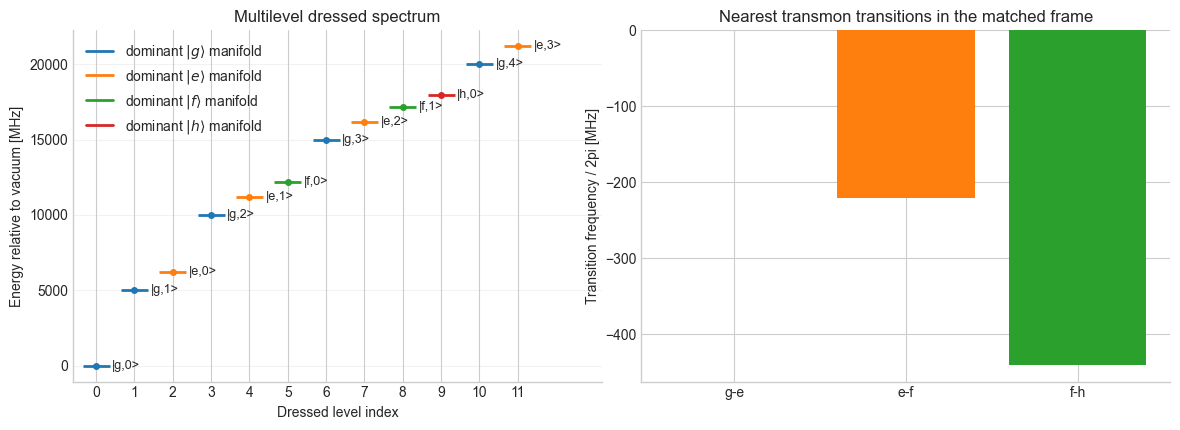

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
plot_energy_levels(spectrum, max_levels=max_levels, energy_scale=1.0 / (2.0 * np.pi * 1.0e6), energy_unit_label="MHz", title="Multilevel dressed spectrum", ax=axes[0])
axes[1].bar(transition_labels, [angular_to_mhz(value) for value in transition_values], color=["tab:blue", "tab:orange", "tab:green"])
axes[1].set_ylabel(r"Transition frequency / 2pi [MHz]")
axes[1].set_title("Nearest transmon transitions in the matched frame")
plt.show()


## 9. Physical Interpretation

The transitions are not equally spaced: the difference between `g-e` and `e-f` is the anharmonicity. That is the physical reason strong resonant `g-e` driving can leak population into `|f>` and higher levels.


## 10. Exercises / Next Steps

- Increase the transmon dimension and compare how the higher ladder continues.
- Change the anharmonicity and see how the `e-f` spacing moves relative to `g-e`.
- Continue to Tutorial 19 for a direct leakage example under stronger drive.
